In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.ticker as mticker

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
FFT_SUMMARY_PATH = ("/content/drive/MyDrive/thesis_results/AAPD_DistilBERT_Learning_Curve_epochs/aapd_learning_curve_summary.csv")

PFEIFFER_SUMMARY_PATH = ("/content/drive/MyDrive/thesis_results/AAPD_DistilBERT_Pfeiffer_Learning_Curve_epochs/aapd_Pfeiffer_learning_curve_summary.csv")

In [ ]:
fft_summary = pd.read_csv(FFT_SUMMARY_PATH)
pfeiffer_summary = pd.read_csv(PFEIFFER_SUMMARY_PATH)

In [ ]:
#adding full training-set size results
full_fft_summary = pd.read_csv("/content/drive/MyDrive/thesis_results/AAPD_DistilBERT/test/AAPD_DistilBERT_test_results_summary.csv", index_col=0)

full_pfeiffer_summary = pd.read_csv("/content/drive/MyDrive/thesis_results/AAPD_DistilBERT_Pfeiffer/test/AAPD_DistilBERT_Pfeiffer_test_results_summary.csv", index_col=0)

In [ ]:
fft_full_row = pd.DataFrame({
    "training_size": [53840],
    "macro_f1_mean": [
        full_fft_summary.loc["mean", "test_f1_macro"]
    ],
    "macro_f1_std": [
        full_fft_summary.loc["std", "test_f1_macro"]
    ],
    "micro_f1_mean": [
        full_fft_summary.loc["mean", "test_f1_micro"]
    ],
    "micro_f1_std": [
        full_fft_summary.loc["std", "test_f1_micro"]
    ]})

In [ ]:
pfeiffer_full_row = pd.DataFrame({
    "training_size": [53840],
    "macro_f1_mean": [
        full_pfeiffer_summary.loc["mean", "test_f1_macro"]
    ],
    "macro_f1_std": [
        full_pfeiffer_summary.loc["std", "test_f1_macro"]
    ],
    "micro_f1_mean": [
        full_pfeiffer_summary.loc["mean", "test_f1_micro"]
    ],
    "micro_f1_std": [
        full_pfeiffer_summary.loc["std", "test_f1_micro"]
    ]})

In [ ]:
fft_summary = (
    pd.concat([fft_summary, fft_full_row], ignore_index=True).drop_duplicates(subset="training_size",keep="last").sort_values("training_size").reset_index(drop=True))

pfeiffer_summary = (pd.concat([pfeiffer_summary, pfeiffer_full_row], ignore_index=True).drop_duplicates(subset="training_size", keep="last").sort_values("training_size").reset_index(drop=True))

In [ ]:
fft_summary["method"] = "Full fine-tuning"
pfeiffer_summary["method"] = "Pfeiffer adapters"

summary_df = (pd.concat([fft_summary, pfeiffer_summary], ignore_index=True).sort_values(["method", "training_size"]).reset_index(drop=True))

display(summary_df)

,training_size,macro_f1_mean,macro_f1_std,micro_f1_mean,micro_f1_std,training_time_mean,training_time_std,epochs_mean,method
0,500,0.161395,0.009775,0.503521,0.007108,1645.953053,109.671430,30.000000,Full fine-tuning
1,1000,0.304221,0.007815,0.590774,0.007018,1982.476476,103.470534,29.333333,Full fine-tuning
2,2500,0.423957,0.007028,0.649675,0.004040,2533.854641,320.086276,28.000000,Full fine-tuning
3,5000,0.470775,0.010243,0.670210,0.007069,2988.430568,749.227282,25.666667,Full fine-tuning
4,10000,0.520721,0.004509,0.688788,0.006036,3729.375449,1129.815720,22.333333,Full fine-tuning
5,53840,0.577532,0.010762,0.729662,0.001418,NaN,NaN,NaN,Full fine-tuning
6,500,0.287025,0.002119,0.577301,0.003508,316.427281,34.667682,28.000000,Pfeiffer adapters
7,1000,0.380336,0.031603,0.613687,0.012525,406.327267,92.162150,24.333333,Pfeiffer adapters
8,2500,0.432412,0.010317,0.647963,0.004830,792.207867,183.290908,23.666667,Pfeiffer adapters
9,5000,0.473394,0.010177,0.674077,0.005352,1335.271358,452.266632,21.666667,Pfeiffer adapters


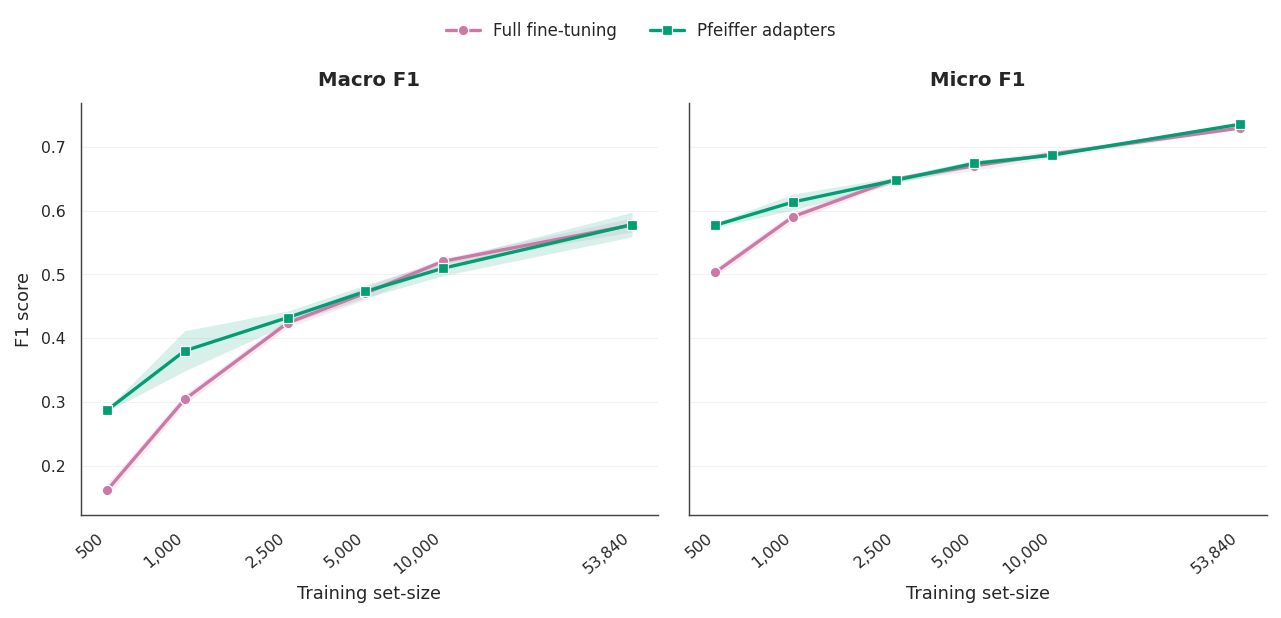

In [ ]:
#figure
mpl.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.titleweight": "bold",
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 8,
    "axes.linewidth": 0.7,
    "figure.dpi": 150})
sns.set_style("white")

colors = {
    "Full fine-tuning": "#CC79A7",
    "Pfeiffer adapters": "#009E73"}
markers = {
    "Full fine-tuning": "o",
    "Pfeiffer adapters": "s"}
methods = ["Full fine-tuning", "Pfeiffer adapters"]
metrics = [
    ("macro_f1_mean", "macro_f1_std", "Macro F1"),
    ("micro_f1_mean", "micro_f1_std", "Micro F1")]
training_sizes = sorted(summary_df["training_size"].unique())


fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharex=True, sharey=True)

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    for method in methods:
        plot_df = (
            summary_df[summary_df["method"] == method]
            .sort_values("training_size"))
        x = plot_df["training_size"].to_numpy()
        mean = plot_df[mean_col].to_numpy()
        std = plot_df[std_col].fillna(0).to_numpy()

        ax.plot(
            x, mean,
            label=method,
            color=colors[method],
            marker=markers[method],
            markersize=5,
            linewidth=1.6,
            markeredgecolor="white",
            markeredgewidth=0.6,
            zorder=3)
        ax.fill_between(
            x, mean - std, mean + std,
            color=colors[method],
            alpha=0.15,
            linewidth=0,
            zorder=2)

    ax.set_title(title, fontweight="bold", pad=8)
    ax.set_xlabel("Training set-size")

    # Log scale, needed because the training set sizes didnt fit
    ax.set_xscale("log")
    ax.set_xticks(training_sizes)
    ax.set_xticklabels(
        [f"{int(size):,}" for size in training_sizes],
        rotation=40,
        ha="right",
    )
    ax.xaxis.set_minor_locator(mticker.NullLocator())

    ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.25, zorder=0)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#444444")

axes[0].set_ylabel("F1 score")


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=False,
)

fig.tight_layout()

#saving
fig.savefig("AAPD_DistilBERT_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()